In [2]:
import polars as pl
from plotnine import *
import re

theme_set(theme_bw())

In [3]:
# command for generating the s3_status.json file (it isn't actually JSON though, don't know why)
# aws s3 ls --output json s3://sandpiper-woodcrob/test/ >s3_status.json
# aws s3 ls --output json s3://woodcrob-sandpiper-us-east-1/unannotated/ >s3_status.json


# Preprocess the file
with open('s3_status.json', 'r') as file:
    content = file.read()

# Replace multiple delimiters with a single delimiter (e.g., ',')
content = re.sub(r' +', ' ', content)

# Write the preprocessed content to a temporary file
with open('/tmp/temp.csv', 'w') as temp_file:
    temp_file.write(content)

# Read the preprocessed file into Polars
df = pl.read_csv('/tmp/temp.csv')

s3 = pl.read_csv('/tmp/temp.csv', has_header=False, separator=' ')
s3[:3], s3[-3:]

(shape: (3, 4)
 ┌────────────┬──────────┬──────────┬─────────────────────────────────┐
 │ column_1   ┆ column_2 ┆ column_3 ┆ column_4                        │
 │ ---        ┆ ---      ┆ ---      ┆ ---                             │
 │ str        ┆ str      ┆ i64      ┆ str                             │
 ╞════════════╪══════════╪══════════╪═════════════════════════════════╡
 │ 2025-02-27 ┆ 11:07:53 ┆ 99372    ┆ DRR014160.unannotated.singlem.… │
 │ 2025-02-27 ┆ 14:30:53 ┆ 35501    ┆ DRR027577.unannotated.singlem.… │
 │ 2025-02-27 ┆ 12:47:59 ┆ 572255   ┆ DRR046090.unannotated.singlem.… │
 └────────────┴──────────┴──────────┴─────────────────────────────────┘,
 shape: (3, 4)
 ┌────────────┬──────────┬──────────┬─────────────────────────────────┐
 │ column_1   ┆ column_2 ┆ column_3 ┆ column_4                        │
 │ ---        ┆ ---      ┆ ---      ┆ ---                             │
 │ str        ┆ str      ┆ i64      ┆ str                             │
 ╞════════════╪══════════╪═══════

In [4]:
s3.columns = ['date', 'time', 'size','file']
s3[:3]

date,time,size,file
str,str,i64,str
"""2025-02-27""","""11:07:53""",99372,"""DRR014160.unannotated.singlem.…"
"""2025-02-27""","""14:30:53""",35501,"""DRR027577.unannotated.singlem.…"
"""2025-02-27""","""12:47:59""",572255,"""DRR046090.unannotated.singlem.…"


In [5]:
s3 = s3.with_columns(pl.col('file').str.split('.').list.get(0).alias('acc'))
# date and time are in separate columns, so we need to combine them into a single column datetime
s3 = s3.with_columns((pl.col('date') + ' ' + pl.col('time')).str.to_datetime("%Y-%m-%d %H:%M:%S").alias('datetime'))
s3[:3]

date,time,size,file,acc,datetime
str,str,i64,str,str,datetime[μs]
"""2025-02-27""","""11:07:53""",99372,"""DRR014160.unannotated.singlem.…","""DRR014160""",2025-02-27 11:07:53
"""2025-02-27""","""14:30:53""",35501,"""DRR027577.unannotated.singlem.…","""DRR027577""",2025-02-27 14:30:53
"""2025-02-27""","""12:47:59""",572255,"""DRR046090.unannotated.singlem.…","""DRR046090""",2025-02-27 12:47:59


In [6]:
# Original data
acc20k = pl.read_csv('runlists/acc_less_than_20k_mbytes.csv', has_header=False)
acc20k.columns = ['acc']
acc20k[:3]

df = pl.read_csv('~/git/sandpiper/sra_metadata/sra_metadata_20250220.some_columns.csv.gz', has_header=False)
df.columns = ['acc','releasedate','mbases','mbytes']
df[:4]

merged20k = acc20k.join(df, on='acc', how='inner')
merged20k[:3], merged20k.shape

(shape: (3, 4)
 ┌─────────────┬───────────────────────────┬────────┬────────┐
 │ acc         ┆ releasedate               ┆ mbases ┆ mbytes │
 │ ---         ┆ ---                       ┆ ---    ┆ ---    │
 │ str         ┆ str                       ┆ i64    ┆ i64    │
 ╞═════════════╪═══════════════════════════╪════════╪════════╡
 │ SRR15442735 ┆ 2021-08-13T00:00:00+00:00 ┆ 6638   ┆ 2614   │
 │ ERR1959224  ┆ 2017-07-08T00:00:00+00:00 ┆ 8555   ┆ 3195   │
 │ ERR5003368  ┆ 2020-12-23T00:00:00+00:00 ┆ 1013   ┆ 344    │
 └─────────────┴───────────────────────────┴────────┴────────┘,
 (710928, 4))

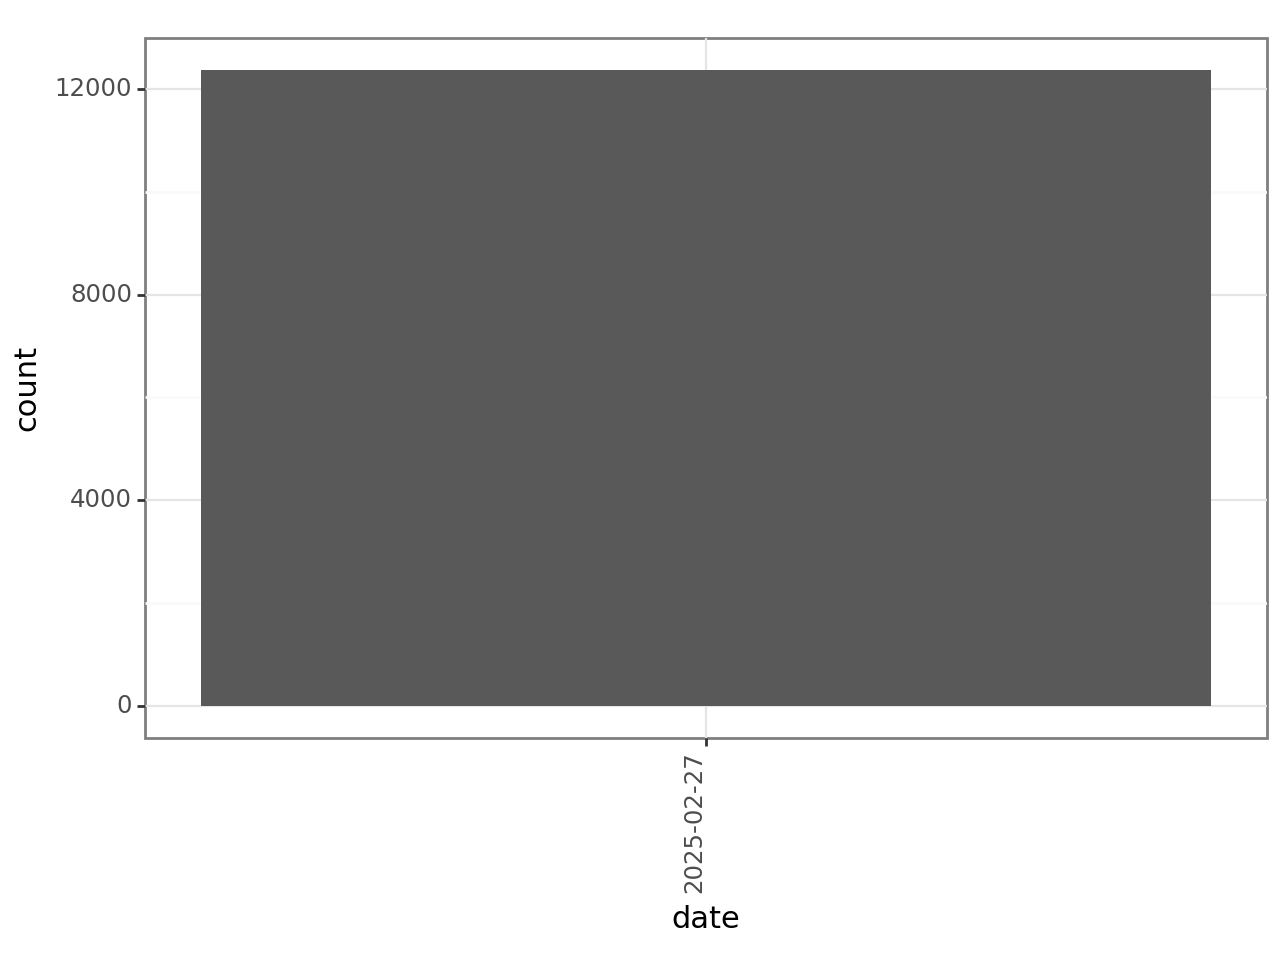

<Figure Size: (640 x 480)>

In [7]:
# plot number of acc finished per day
ggplot(data=s3)+geom_bar(aes(x='date'))+theme(axis_text_x=element_text(rotation=90, hjust=1))

In [8]:
# Are larger files being processed? Plot the number of files processed per day, colored by size
joined = merged20k.join(s3, on='acc', how='left')
joined.filter(pl.col('size')>0)[:3]

acc,releasedate,mbases,mbytes,date,time,size,file,datetime
str,str,i64,i64,str,str,i64,str,datetime[μs]
"""ERR2603234""","""2018-07-03T00:00:00+00:00""",1544,645,"""2025-02-27""","""15:25:19""",490196,"""ERR2603234.unannotated.singlem…",2025-02-27 15:25:19
"""ERR11478487""","""2023-09-11T00:00:00+00:00""",7103,2172,"""2025-02-27""","""12:09:08""",1302955,"""ERR11478487.unannotated.single…",2025-02-27 12:09:08
"""SRR8884589""","""2019-06-17T00:00:00+00:00""",1138,513,"""2025-02-27""","""14:50:22""",370657,"""SRR8884589.unannotated.singlem…",2025-02-27 14:50:22


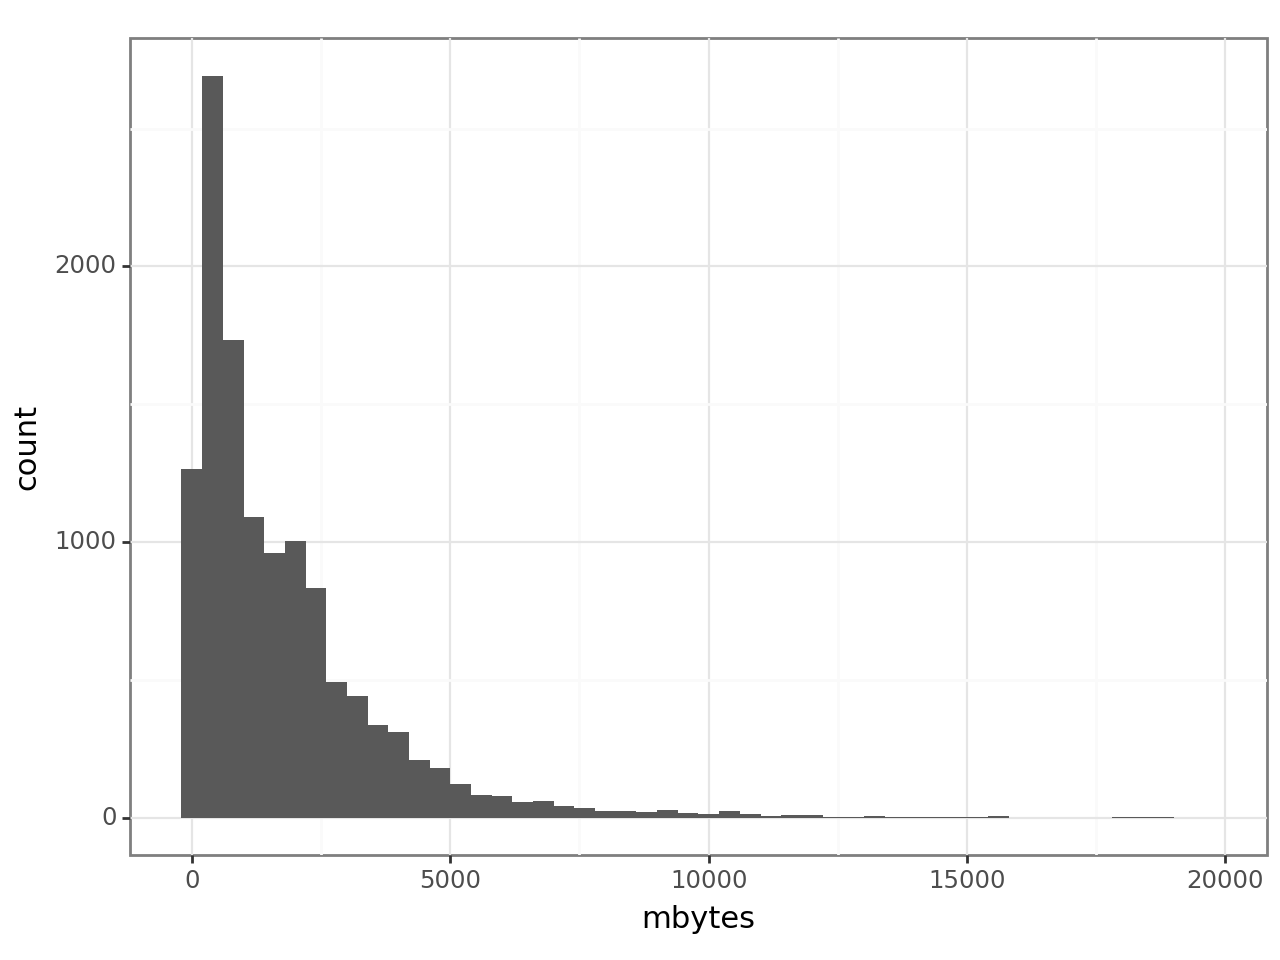

<Figure Size: (640 x 480)>

In [9]:
ggplot(joined.filter(pl.col('size')>0))+geom_histogram(aes(x='mbytes'), bins=50)

shape: (2, 2)
┌───────┬────────┐
│ done  ┆ len    │
│ ---   ┆ ---    │
│ bool  ┆ u32    │
╞═══════╪════════╡
│ true  ┆ 12364  │
│ false ┆ 698564 │
└───────┴────────┘


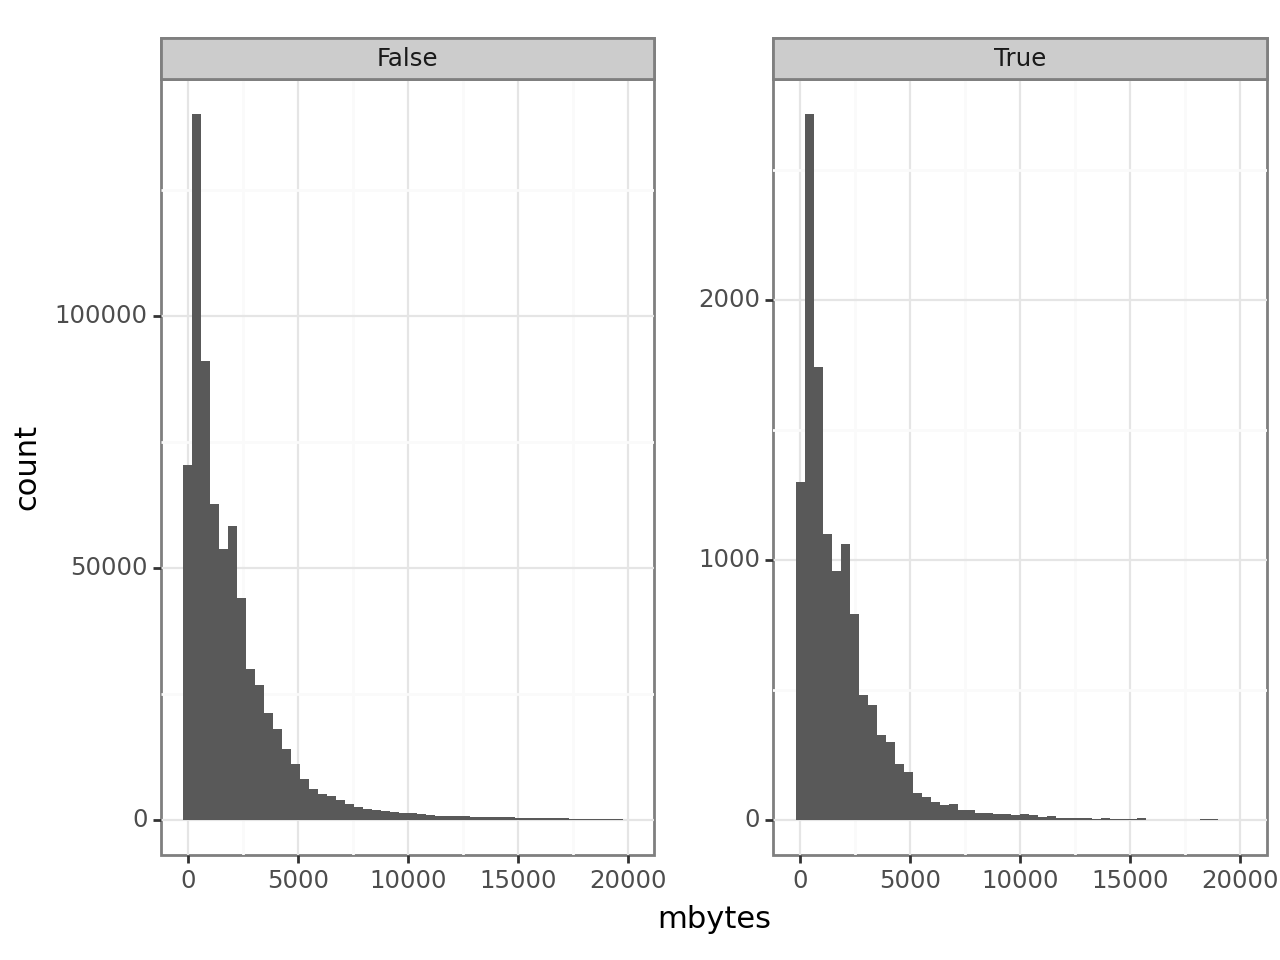

<Figure Size: (640 x 480)>

In [10]:
joined = joined.with_columns(~pl.col('size').is_null().alias('done'))
print(joined.group_by('done').len())
# ggplot(joined)+geom_density(aes(x='mbases'))#, colour='done')
# ggplot(joined.filter(pl.col('done')))+geom_histogram(aes(x='mbytes'), bins=50)
ggplot(joined)+geom_histogram(aes(x='mbytes'), bins=50)+ facet_wrap('done', scales='free_y')

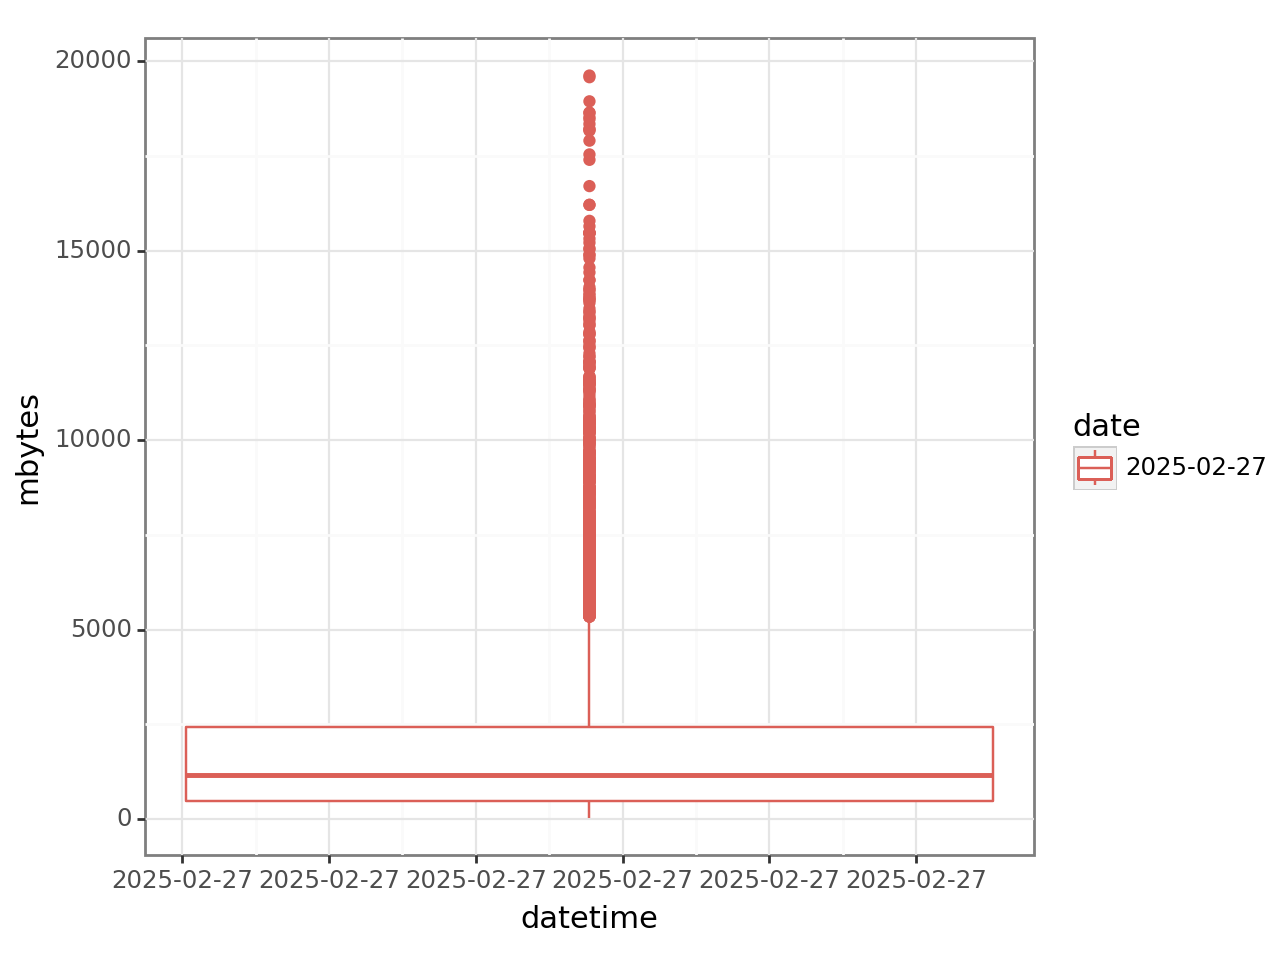

<Figure Size: (640 x 480)>

In [11]:
# Plot size vs date
ggplot(joined.filter(pl.col('done')))+geom_boxplot(aes(x='datetime', y='mbytes', colour='date'))

In [12]:
joined.filter(pl.col('done')).select('date','mbytes').group_by('date').median(), joined.select(pl.col('mbytes')).median()

(shape: (1, 2)
 ┌────────────┬────────┐
 │ date       ┆ mbytes │
 │ ---        ┆ ---    │
 │ str        ┆ f64    │
 ╞════════════╪════════╡
 │ 2025-02-27 ┆ 1171.0 │
 └────────────┴────────┘,
 shape: (1, 1)
 ┌────────┐
 │ mbytes │
 │ ---    │
 │ f64    │
 ╞════════╡
 │ 1319.0 │
 └────────┘)

In [13]:
# DONT DO THIS - RAM ISSUES
# # ggplot(joined)+geom_density(aes(x='mbytes', colour='done'))

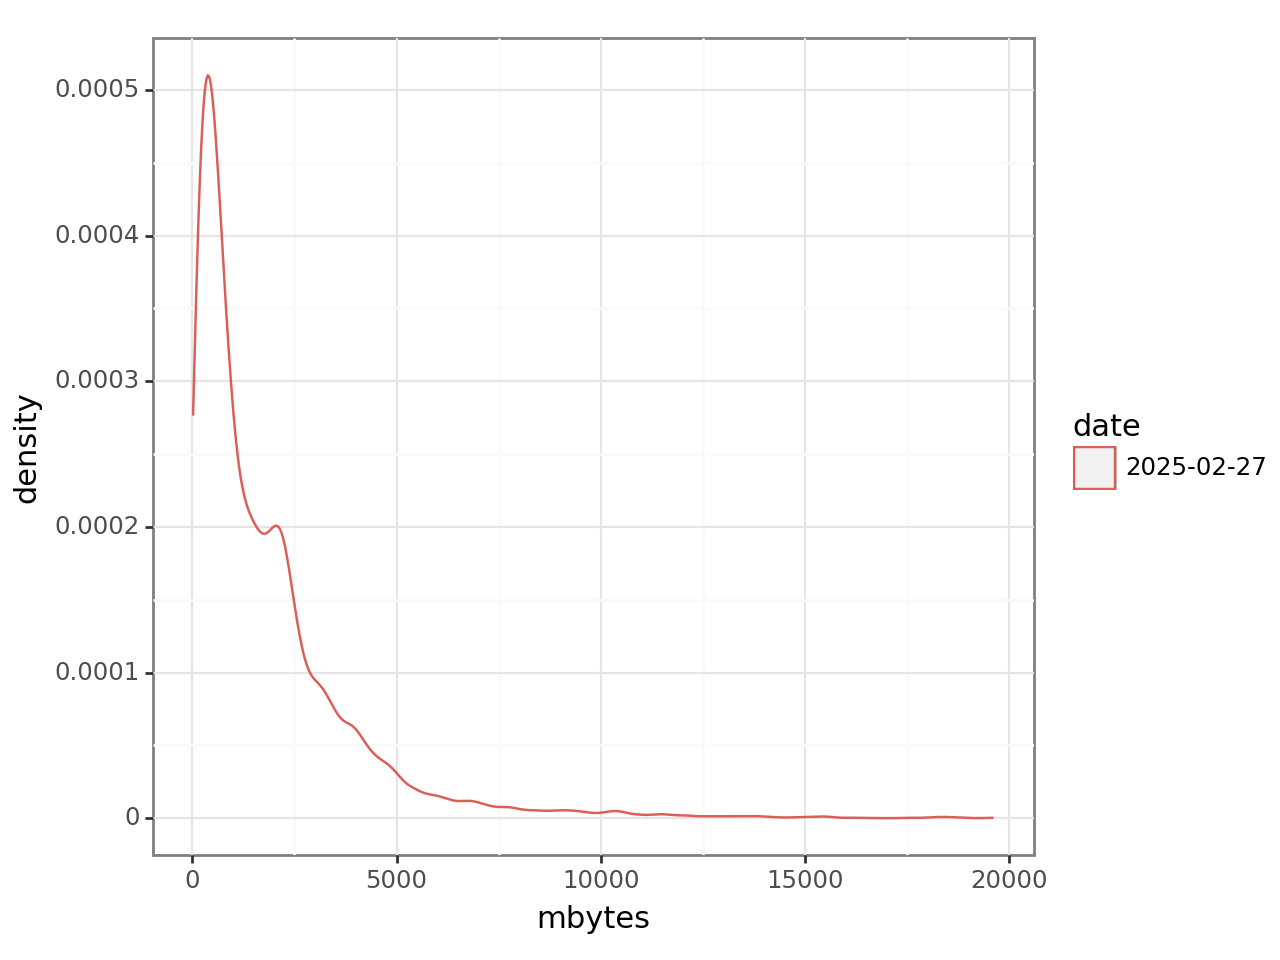

<Figure Size: (640 x 480)>

In [14]:
ggplot(joined.filter(pl.col('done')))+geom_density(aes(x='mbytes', colour='date'))

In [17]:
# estimate total time required to process all files. Time taken is the time since the first file appeared in the S3 bucket
start_time = joined.filter(pl.col('done')).with_columns(pl.col('datetime').min().alias('start'))['start'][0]
# joined.filter(pl.col('datetime')==start_time)
print(start_time)
import datetime
time_since_start = datetime.datetime.now() - start_time
print(time_since_start)
num_to_do = joined.shape[0] - 18831 # minus us-east-2
num_to_do / joined.filter(pl.col('done')).shape[0] * time_since_start, joined.group_by('done').len()

# but that's an underestimate because smaller files are processed faster, so more likely to be already done.

2025-02-27 09:43:03
6:11:10.883768


(datetime.timedelta(days=14, seconds=37052, microseconds=526948),
 shape: (2, 2)
 ┌───────┬────────┐
 │ done  ┆ len    │
 │ ---   ┆ ---    │
 │ bool  ┆ u32    │
 ╞═══════╪════════╡
 │ false ┆ 698564 │
 │ true  ┆ 12364  │
 └───────┴────────┘)